In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [8]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [3]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB_ARRAYS IS RUNNING
plotting=True

In [4]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [44]:
def GetVars(var_names,type1):
    input_file = dir2 + f'job_out/{type1}_eulerian_entrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    with h5py.File(input_file, 'r') as f:
        for var in var_names:
            globals()[f"{var}_{type1[0]}"] = f[f"profile_array_{var}_{type1[0]}"][:]

            # globals()[f"{var}_{type1[0]}_SE"]=ProfileStandardError(f[f"profile_array_{var}_{type1[0]}"][:],f[f"profile_array_{var}_{type1[0]}_squares"][:])
            globals()[f"{var}_{type1[0]}_SE"]=ProfileStandardDeviation(f[f"profile_array_{var}_{type1[0]}"][:],f[f"profile_array_{var}_{type1[0]}_squares"][:])


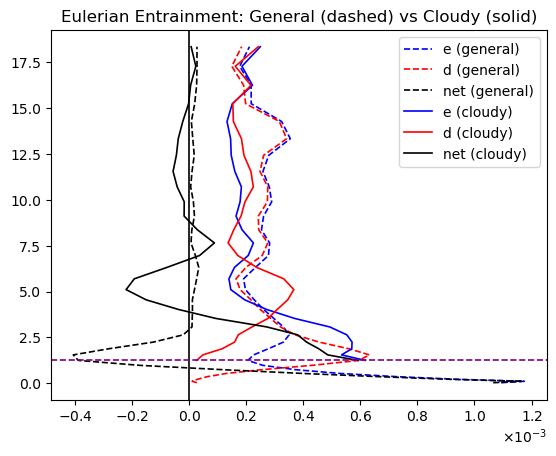

In [45]:
if plotting == True:
    dir2 = dir + 'Project_Algorithms/Domain_Profiles/'


    var_names=['e','d','net']
    # # --- Load General ---
    type1='general'
    GetVars(var_names,type1)
    # # --- Load Cloudy ---
    type1='cloudy'
    GetVars(var_names,type1)

    # --- Process Both Types ---
    out_e_g = averaged_profiles(e_g)
    out_d_g = averaged_profiles(d_g)
    out_net_g = averaged_profiles(net_g)

    out_e_c = averaged_profiles(e_c)
    out_d_c = averaged_profiles(d_c)
    out_net_c = averaged_profiles(net_c)

    # --- Plot ---
    lw = 1.2  # Line width
    factor=1;#factor=1.96
    # plt.plot(out_e_g[:, 0], out_e_g[:, 1], color='blue', linestyle='--', linewidth=lw, label='e (general)')
    # plt.plot(out_d_g[:, 0], out_d_g[:, 1], color='red', linestyle='--', linewidth=lw, label='d (general)')
    # plt.plot(out_net_g[:, 0], out_net_g[:, 1], color='k', linestyle='--', linewidth=lw, label='net (general)')

    # plt.plot(out_e_c[:, 0], out_e_c[:, 1], color='blue', linestyle='-', linewidth=lw, label='e (cloudy)')
    # plt.plot(out_d_c[:, 0], out_d_c[:, 1], color='red', linestyle='-', linewidth=lw, label='d (cloudy)')
    # plt.plot(out_net_c[:, 0], out_net_c[:, 1], color='k', linestyle='-', linewidth=lw, label='net (cloudy)')
    
    var_names = ['e', 'd', 'net']
    colors = {'e': 'blue', 'd': 'red', 'net': 'k'}
    styles = {'g': '--', 'c': '-'}
    
    for suffix in ['g', 'c']:
        for var in var_names:
            varname = f'out_{var}_{suffix}'
            profile = globals()[varname]
            profile_SE = globals()[f'{var}_{suffix}_SE']  # optional, in case SE isn't available
    
            label_suffix = 'general' if suffix == 'g' else 'cloudy'
            plt.plot(
                profile[:, 0],
                profile[:, 1],
                color=colors[var],
                linestyle=styles[suffix],
                linewidth=lw,
                label=f'{var} ({label_suffix})'
            )
    
            # plt.fill_betweenx(
            #     profile[:, 1],
            #     profile[:, 0] - factor * profile_SE[:, 0],
            #     profile[:, 0] + factor * profile_SE[:, 0],
            #     color=colors[var],
            #     alpha=0.1
            # )

    # --- Error Plot ---
    # profile=out_e_
    # axis.fill_betweenx(profile[:, 1], profile[:, 0] - factor*profile_SE[:,0]*switch, profile[:, 0] + factor*profile_SE[:,0], color=color, alpha=0.1)

    # --- Line Plot ---
    plt.axvline(0, color='k', linewidth=lw)
    
    # --- Cloud Base Line ---
    avg_cloudbase = e_c[:, 2][np.where(e_c[:, 1] != 0)[0][0]]
    plt.axhline(avg_cloudbase, color='purple', linestyle='dashed', linewidth=lw)

    ax = plt.gca()
    apply_scientific_notation([ax])

    plt.title('Eulerian Entrainment: General (dashed) vs Cloudy (solid)')
    plt.legend()


In [28]:
# #DOUBLE CHECKING
# w=data['winterp'].data
# qc=data['qc'].data
# qi=data['qi'].data
# qcqi=qc+qi
# mask = (w >= 0.5) & (qcqi >= 1e-6)
# profile_array_e_c[~mask] = np.nan
# out=np.nanmean(profile_array_e_c,axis=(0,2,3))
# plt.plot(out,data['zh'])
# ax=plt.gca()
# apply_scientific_notation([ax])

In [29]:
# #thresholds
# w_thresh1=0.1
# w_thresh2=0.5
# qcqi_thresh=1e-6

In [27]:
# def plotting(out_var,axis,label,color):
#     axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
#     axis.grid(True)
#     apply_scientific_notation([axis])

# fig, axs = plt.subplots(1, 3, figsize=(15, 10))
# # fig.suptitle()
# ax1,ax2,ax3=axs.flatten()

# for type in ["general","cloudy"]:
#     print(f'currently on type {type}')
#     dir2=dir+'Project_Algorithms/Domain_Profiles/'
#     if type == "general":
#         input_file = dir2+f'job_out/general_eulerian_entrainment_profiles_{res}_{Np_str}_5min.h5' 
#     elif type == "cloudy":
#         input_file = dir2+f'job_out/cloudy_eulerian_entrainment_profiles_{res}_{Np_str}_5min.h5' 

#     with h5py.File(input_file, 'r') as f:
#         if type == "general":
#             e = np.array(f['profile_e_g'])
#             d = np.array(f['profile_d_g'])
#             net = np.array(f['profile_net_g'])
#         elif type == "cloudy":
#             e = np.array(f['profile_e_c'])
#             d = np.array(f['profile_d_c'])
#             net = np.array(f['profile_net_c'])

#     #Uses Averaged_Profiles Function
#     vars = ['e','d','net'] 
    
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(globals()[f"{var}"])
        
#     axises=[ax1,ax2,ax3] 
#     xlabels=['e','d','net'] 
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'

#         plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

#         if axis==ax1:
#             axis.legend()
#         axis.axvline(0,color='k')

#     type='cloudy'
#     #MEAN CLOUD BASE
#     dir2=dir+'Project_Algorithms/Domain_Profiles/'
#     if type == "general":
#         input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{Np_str}_5min.h5' 
#     elif type == "cloudy":
#         input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{Np_str}_5min.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         profile_qc = np.array(f['profile_qc'])
#         qcqi_profile=averaged_profiles(profile_qc)
#         where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
#         cloudbase=qcqi_profile[where_cloudbase,1]
#         for axis in axises:
#             axis.axhline(cloudbase,color='purple',linestyle='dashed')
        